# Classificação do tamanho do alvo pelo movimento do mouse

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/alangnclvs/mouse-pointing-tsc/blob/main/03_pointing_classification.ipynb)

Trabalho final de Mineração de Séries Temporais - Alan Gonçalves

Neste trabalho eu coletei movimentos do mouse numa tarefa simples: clicar num círculo no centro da tela e depois num alvo que aparece a 300 px de distância, em uma direção aleatória. O alvo pode ter três tamanhos, que são as classes do problema:

<table style="margin-left: 0">
<tr><th>Classe</th><th>Diâmetro</th><th>Referência (WCAG 2.2)</th></tr>
<tr><td>pequeno</td><td>12 px</td><td>abaixo do tamanho mínimo</td></tr>
<tr><td>médio</td><td>24 px</td><td>tamanho mínimo</td></tr>
<tr><td>grande</td><td>44 px</td><td>tamanho recomendado</td></tr>
</table>

A ideia é ver se dá para descobrir o tamanho do alvo só pela velocidade do cursor durante o movimento. Pela lei de Fitts, alvos menores deveriam levar mais tempo para serem atingidos.

Os dados estão em [github.com/alangnclvs/mouse-pointing-tsc](https://github.com/alangnclvs/mouse-pointing-tsc). Como classificador usei catch22 + Random Forest e, como baseline, o 1NN-DTW.

## 1. Ambiente e dados

Instalação do `aeon` e download do repositório com os dados.

In [37]:
!pip install -q aeon==1.6.0
!test -d mouse-pointing-tsc || git clone -q https://github.com/alangnclvs/mouse-pointing-tsc.git

In [38]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from aeon.classification.distance_based import KNeighborsTimeSeriesClassifier
from aeon.transformations.collection.feature_based import Catch22
from scipy.stats import binomtest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
CLASSES = ["small", "medium", "large"]
CLASS_NAMES = {"small": "pequeno", "medium": "médio", "large": "grande"}
ORDER = list(CLASS_NAMES.values())
PALETTE = dict(zip(ORDER, ["#2a78d6", "#eb6834", "#1baf7a"]))

O `trials.csv` tem uma linha para cada movimento. A divisão entre treino e teste já está no repositório: as sessões 1, 3 e 5 são de treino e as sessões 2, 4 e 6 de teste. Cada série tem as colunas `t` (tempo em segundos desde que o alvo apareceu), `x` e `y` (posição do cursor em pixels).

In [39]:
DATA = Path("mouse-pointing-tsc/data")
trials = pd.read_csv(DATA / "trials.csv")
trials["classe"] = pd.Categorical(trials["size_label"].map(CLASS_NAMES), ORDER)
trials["conjunto"] = pd.Categorical(trials["split"].map({"train": "treino", "test": "teste"}), ["treino", "teste"])
raw_series = [pd.read_csv(DATA / path) for path in trials["path"]]

train_sessions = sorted(trials.loc[trials["split"] == "train", "session"].unique())
test_sessions = sorted(trials.loc[trials["split"] == "test", "session"].unique())
assert set(train_sessions).isdisjoint(test_sessions)
print("Sessões de treino:", [int(s) for s in train_sessions], "| sessões de teste:", [int(s) for s in test_sessions])
display(pd.crosstab(trials["conjunto"], trials["classe"]))
display(raw_series[0].head())

Sessões de treino: [1, 3, 5] | sessões de teste: [2, 4, 6]


classe,pequeno,médio,grande
conjunto,,,
treino,30,30,30
teste,30,30,30


,t,x,y
0,0.000000,1274,533
1,0.199142,1271,537
2,0.203414,1271,540
3,0.211049,1266,546
4,0.223149,1258,555


## 2. Exploração

Primeiro olhei o tempo de cada movimento por classe. Deixei treino e teste lado a lado só para comparar, nada do teste foi usado para tomar decisões.

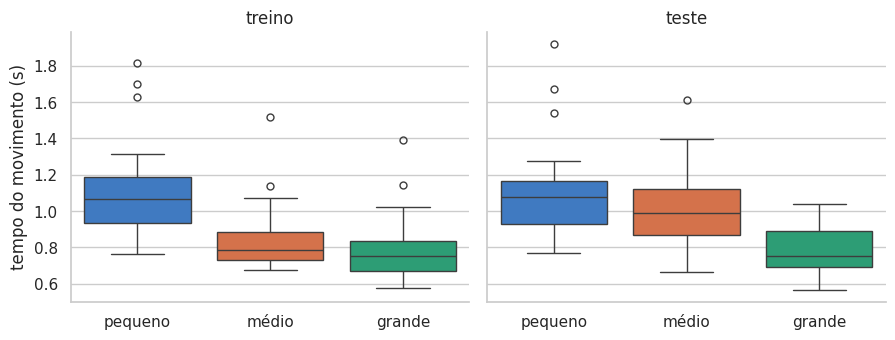

tempo_medio_s  desvio_s  cliques_errados
conjunto classe                                           
treino   pequeno          1.091     0.260                9
         médio            0.839     0.171                1
         grande           0.785     0.176                7
teste    pequeno          1.101     0.254                4
         médio            1.018     0.199                4
         grande           0.781     0.131                2

In [40]:
grid = sns.catplot(data=trials, x="classe", y="movement_time_s", col="conjunto", kind="box",
                   hue="classe", palette=PALETTE, legend=False, height=3.8, aspect=1.2)
grid.set_axis_labels("", "tempo do movimento (s)").set_titles("{col_name}")
plt.show()

summary = trials.groupby(["conjunto", "classe"], observed=True).agg(
    tempo_medio_s=("movement_time_s", "mean"),
    desvio_s=("movement_time_s", "std"),
    cliques_errados=("n_misses", "sum"),
)
display(summary.round(3))

Pela lei de Fitts, o tempo cresce de forma linear com o índice de dificuldade $ID = \log_2(D/W + 1)$, onde $D$ é a distância e $W$ a largura do alvo. Testei isso com os dados de treino:

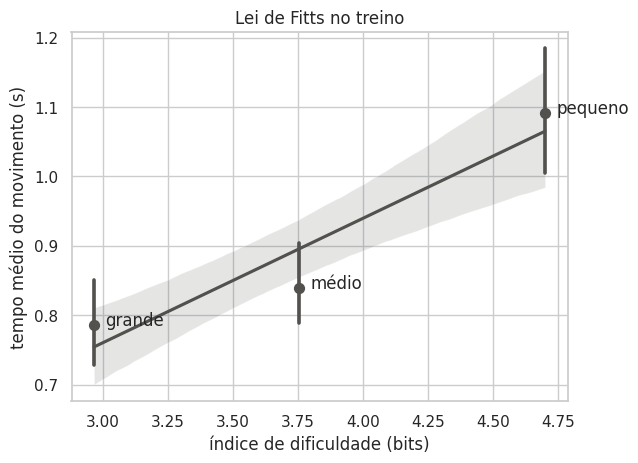

tempo = 0.222 + 0.179 × ID


In [41]:
train = trials[trials["split"] == "train"].copy()
train["id_bits"] = np.log2(train["distance_px"] / train["width_px"] + 1)
slope, intercept = np.polyfit(train["id_bits"], train["movement_time_s"], 1)

ax = sns.regplot(data=train, x="id_bits", y="movement_time_s", x_estimator=np.mean, seed=RANDOM_STATE, color="#52514e")
for classe, group in train.groupby("classe", observed=True):
    ax.annotate(classe, (group["id_bits"].iloc[0], group["movement_time_s"].mean()), xytext=(8, 0), textcoords="offset points")
ax.set(xlabel="índice de dificuldade (bits)", ylabel="tempo médio do movimento (s)", title="Lei de Fitts no treino")
plt.show()
print(f"tempo = {intercept:.3f} + {slope:.3f} × ID")

## 3. Pré-processamento

Cada movimento passou por estas etapas:

1. Segmentação: já vem da coleta. Cada movimento começa quando o alvo aparece e termina no clique que acerta o alvo.
2. Reamostragem para 100 Hz: o mouse só manda a posição quando se mexe, então coloquei as posições numa grade de tempo regular, repetindo a última posição enquanto o cursor fica parado.
3. Magnitude: calculei a velocidade a partir do deslocamento em x e y. Assim a série fica univariada e a direção do alvo deixa de importar. Também usei uma média móvel de 5 pontos para suavizar.
4. Trimming: tirei o tempo de reação do começo, considerando que o movimento começa quando a velocidade passa de 10% do pico.

A normalização (z-score) ficou como parâmetro a ser testado na seção 4.

In [42]:
FS = 100


def cursor_speed(df):
    grid = np.arange(0, df["t"].iloc[-1], 1 / FS)
    idx = np.searchsorted(df["t"], grid, side="right") - 1
    x, y = df["x"].to_numpy(float)[idx], df["y"].to_numpy(float)[idx]
    speed = np.hypot(np.diff(x), np.diff(y)) * FS
    return pd.Series(speed).rolling(5, center=True, min_periods=1).mean().to_numpy()


def trim_onset(speed):
    onset = int(np.argmax(speed >= 0.1 * speed.max()))
    return speed[onset:]


def z_normalize(series):
    return (series - series.mean()) / (series.std() + 1e-8)


full_speeds = [cursor_speed(s) for s in raw_series]
speeds = [trim_onset(s) for s in full_speeds]
trials["duration_s"] = [len(s) / FS for s in speeds]
print(f"Pontos por série após o pré-processamento: mínimo {min(map(len, speeds))}, média {np.mean([len(s) for s in speeds]):.0f}, máximo {max(map(len, speeds))}")

Pontos por série após o pré-processamento: mínimo 37, média 72, máximo 160


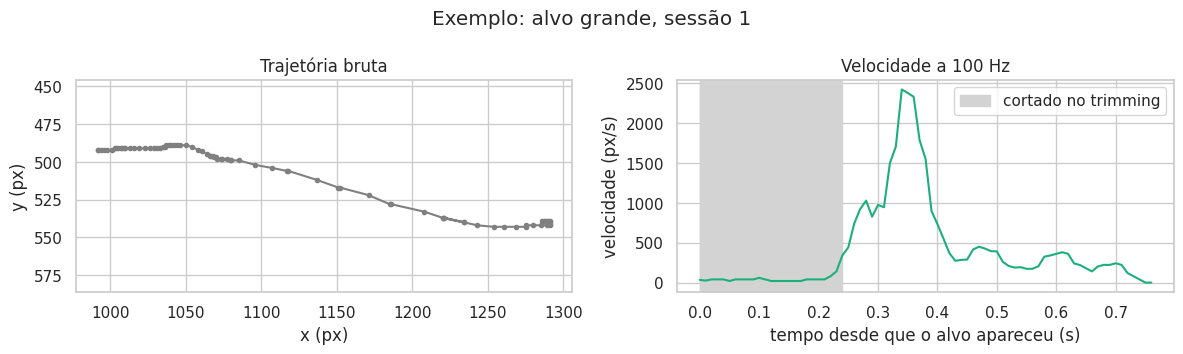

In [43]:
example = 1
speed = full_speeds[example]
onset = int(np.argmax(speed >= 0.1 * speed.max()))
time = np.arange(len(speed)) / FS

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].plot(raw_series[example]["x"], raw_series[example]["y"], marker=".", color="gray")
axes[0].invert_yaxis()
axes[0].set_aspect("equal", adjustable="datalim")
axes[0].set(title="Trajetória bruta", xlabel="x (px)", ylabel="y (px)")
axes[1].plot(time, speed, color=PALETTE[trials.loc[example, "classe"]])
axes[1].axvspan(0, time[onset], color="lightgray", label="cortado no trimming")
axes[1].set(title="Velocidade a 100 Hz", xlabel="tempo desde que o alvo apareceu (s)", ylabel="velocidade (px/s)")
axes[1].legend()
fig.suptitle(f"Exemplo: alvo {trials.loc[example, 'classe']}, sessão {trials.loc[example, 'session']}")
plt.tight_layout()
plt.show()

Abaixo está o perfil médio de velocidade de cada classe no treino, com o tempo normalizado entre 0 (início do movimento) e 1 (clique), para comparar só o formato das curvas.

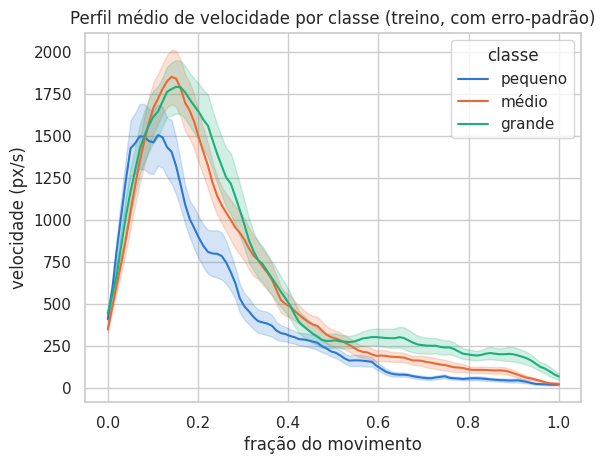

In [44]:
train_idx = np.flatnonzero(trials["split"] == "train")
test_idx = np.flatnonzero(trials["split"] == "test")

profiles = pd.DataFrame([
    {"classe": trials.loc[i, "classe"], "fração do movimento": f, "velocidade (px/s)": v}
    for i in train_idx
    for f, v in zip(np.linspace(0, 1, 100), np.interp(np.linspace(0, 1, 100), np.linspace(0, 1, len(speeds[i])), speeds[i]))
])
ax = sns.lineplot(data=profiles, x="fração do movimento", y="velocidade (px/s)", hue="classe", hue_order=ORDER, palette=PALETTE, errorbar="se")
ax.set_title("Perfil médio de velocidade por classe (treino, com erro-padrão)")
plt.show()

## 4. Protocolo experimental

Usei as sessões 1, 3 e 5 para treino e as sessões 2, 4 e 6 para teste, com 90 movimentos em cada. Para escolher os parâmetros usei só o treino, com validação cruzada deixando uma sessão de fora: treino com duas sessões e valido na terceira, repetindo três vezes. Fiz assim para que movimentos da mesma sessão não ficassem ao mesmo tempo no treino e na validação, do mesmo jeito que acontece entre treino e teste.

Escolhi a configuração com a maior acurácia média na validação. Em caso de empate, fiquei com a de menor desvio e depois com a mais simples. O conjunto de teste só foi usado no final.

In [45]:
labels = trials["size_label"].to_numpy()
sessions = trials["session"].to_numpy()


def session_folds():
    for session in train_sessions:
        yield train_idx[sessions[train_idx] != session], train_idx[sessions[train_idx] == session]

### Baseline: 1NN-DTW

Cada movimento recebe a classe do movimento de treino mais parecido segundo o DTW. Testei o tamanho da janela do DTW (de 0, sem deformação no tempo, até 100%, sem restrição) e duas versões da série: em px/s e z-normalizada.

In [46]:
rows = []
for version, series in {"px/s": speeds, "z-normalizada": [z_normalize(s) for s in speeds]}.items():
    X = [s.reshape(1, -1) for s in series]
    for window in [0.0, 0.05, 0.1, 0.2, 1.0]:
        scores = []
        for fit, val in session_folds():
            knn = KNeighborsTimeSeriesClassifier(n_neighbors=1, distance="dtw", distance_params={"window": window})
            knn.fit([X[i] for i in fit], labels[fit])
            scores.append(accuracy_score(labels[val], knn.predict([X[i] for i in val])))
        rows.append({"série": version, "janela": window, "acurácia": np.mean(scores), "desvio": np.std(scores)})

dtw_cv = pd.DataFrame(rows)
best_dtw = dtw_cv.sort_values(["acurácia", "desvio", "janela"], ascending=[False, True, True], kind="mergesort").iloc[0]
print("Acurácia média na validação (%):")
display((dtw_cv.pivot(index="janela", columns="série", values="acurácia") * 100).round(1))
print(f"Escolhido: série {best_dtw['série']}, janela {best_dtw['janela']:.0%} ({best_dtw['acurácia']:.1%} ± {best_dtw['desvio']:.1%})")

Acurácia média na validação (%):


série,px/s,z-normalizada
janela,,
0.00,36.7,46.7
0.05,42.2,46.7
0.10,41.1,41.1
0.20,40.0,33.3
1.00,32.2,30.0


Escolhido: série z-normalizada, janela 5% (46.7% ± 2.7%)


### Classificador: catch22 + Random Forest

O catch22 extrai 22 características de cada série, como distribuição dos valores, autocorrelação, flutuações e entropia. Calculei essas características sobre a série z-normalizada, então elas descrevem o formato do movimento. Testei três combinações de características (só o catch22; catch22 com a média e o desvio da velocidade; catch22 com média, desvio e duração do movimento) e dois valores de `min_samples_leaf` (1 e 3). O Random Forest tem 500 árvores e semente fixa.

In [47]:
catch22 = Catch22(replace_nans=True)
shape = catch22.fit_transform([z_normalize(s).reshape(1, -1) for s in speeds])
intensity = np.column_stack([[s.mean() for s in speeds], [s.std() for s in speeds]])
duration = trials[["duration_s"]].to_numpy()
catch22_names = list(catch22.get_features_arguments)

representations = {
    "catch22": (shape, catch22_names),
    "catch22 + intensidade": (np.hstack([shape, intensity]), catch22_names + ["speed_mean", "speed_std"]),
    "catch22 + intensidade + duração": (np.hstack([shape, intensity, duration]), catch22_names + ["speed_mean", "speed_std", "duration_s"]),
}

rows = []
for order, (name, (features, _)) in enumerate(representations.items()):
    for leaf in [1, 3]:
        scores = []
        for fit, val in session_folds():
            forest = RandomForestClassifier(n_estimators=500, min_samples_leaf=leaf, random_state=RANDOM_STATE, n_jobs=-1)
            forest.fit(features[fit], labels[fit])
            scores.append(accuracy_score(labels[val], forest.predict(features[val])))
        rows.append({"representação": name, "ordem": order, "min_samples_leaf": leaf, "acurácia": np.mean(scores), "desvio": np.std(scores)})

rf_cv = pd.DataFrame(rows)
best_rf = rf_cv.sort_values(["acurácia", "desvio", "ordem", "min_samples_leaf"], ascending=[False, True, True, False], kind="mergesort").iloc[0]
print("Acurácia média na validação (%):")
display((rf_cv.pivot(index="representação", columns="min_samples_leaf", values="acurácia") * 100).round(1).loc[list(representations)])
print(f"Escolhido: {best_rf['representação']}, min_samples_leaf = {best_rf['min_samples_leaf']} ({best_rf['acurácia']:.1%} ± {best_rf['desvio']:.1%})")

Acurácia média na validação (%):


min_samples_leaf,1,3
representação,,
catch22,54.4,55.6
catch22 + intensidade,53.3,57.8
catch22 + intensidade + duração,55.6,57.8


Escolhido: catch22 + intensidade + duração, min_samples_leaf = 3 (57.8% ± 5.7%)


## 5. Resultados no teste

Com os parâmetros escolhidos, treinei os dois modelos com os 90 movimentos de treino e avaliei uma única vez nos 90 de teste. Também usei o teste de McNemar, que compara os dois modelos nos mesmos exemplos olhando só os casos em que um acerta e o outro erra.

In [48]:
X_dtw = [s.reshape(1, -1) for s in (speeds if best_dtw["série"] == "px/s" else [z_normalize(s) for s in speeds])]
baseline = KNeighborsTimeSeriesClassifier(n_neighbors=1, distance="dtw", distance_params={"window": best_dtw["janela"]})
baseline.fit([X_dtw[i] for i in train_idx], labels[train_idx])

features, feature_names = representations[best_rf["representação"]]
forest = RandomForestClassifier(n_estimators=500, min_samples_leaf=int(best_rf["min_samples_leaf"]), random_state=RANDOM_STATE, n_jobs=-1)
forest.fit(features[train_idx], labels[train_idx])

y_test = labels[test_idx]
predictions = {
    "1NN-DTW (baseline)": baseline.predict([X_dtw[i] for i in test_idx]),
    "catch22 + Random Forest": forest.predict(features[test_idx]),
}

test = trials.iloc[test_idx].copy()
for name, pred in predictions.items():
    test[name] = pred == y_test

accuracy = test.groupby("session")[list(predictions)].mean().T * 100
accuracy.columns = [f"sessão {s}" for s in accuracy.columns]
accuracy.insert(0, "teste completo", test[list(predictions)].mean() * 100)
print("Acurácia no teste (%):")
display(accuracy.round(1))

only_rf = int((test["catch22 + Random Forest"] & ~test["1NN-DTW (baseline)"]).sum())
only_dtw = int((test["1NN-DTW (baseline)"] & ~test["catch22 + Random Forest"]).sum())
print(f"Acertos exclusivos: Random Forest {only_rf}, 1NN-DTW {only_dtw} | McNemar: p = {binomtest(only_rf, only_rf + only_dtw).pvalue:.3f}")
print(f"Acerto ao acaso com 3 classes balanceadas: {1 / 3:.1%}")

Acurácia no teste (%):


,teste completo,sessão 2,sessão 4,sessão 6
1NN-DTW (baseline),34.4,36.7,23.3,43.3
catch22 + Random Forest,53.3,63.3,40.0,56.7


Acertos exclusivos: Random Forest 31, 1NN-DTW 14 | McNemar: p = 0.016
Acerto ao acaso com 3 classes balanceadas: 33.3%


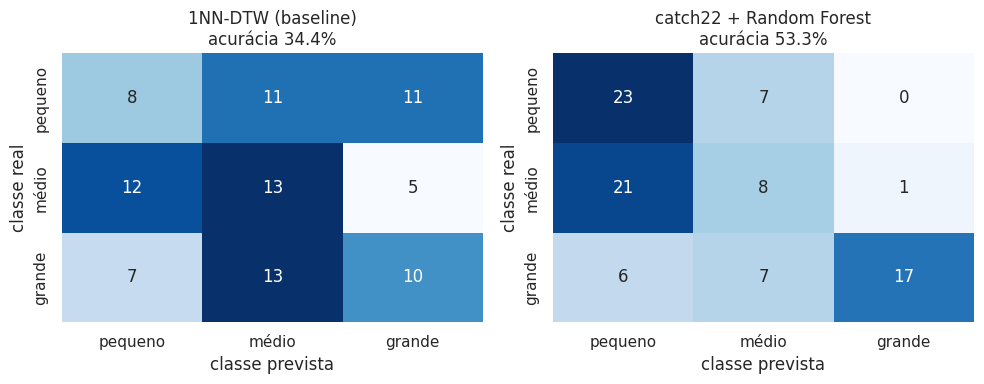

1NN-DTW (baseline)
              precision    recall  f1-score   support

     pequeno      0.296     0.267     0.281        30
       médio      0.351     0.433     0.388        30
      grande      0.385     0.333     0.357        30

    accuracy                          0.344        90
   macro avg      0.344     0.344     0.342        90
weighted avg      0.344     0.344     0.342        90

catch22 + Random Forest
              precision    recall  f1-score   support

     pequeno      0.460     0.767     0.575        30
       médio      0.364     0.267     0.308        30
      grande      0.944     0.567     0.708        30

    accuracy                          0.533        90
   macro avg      0.589     0.533     0.530        90
weighted avg      0.589     0.533     0.530        90



In [49]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, pred) in zip(axes, predictions.items()):
    matrix = confusion_matrix(y_test, pred, labels=CLASSES)
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=ORDER, yticklabels=ORDER, ax=ax)
    ax.set(title=f"{name}\nacurácia {accuracy_score(y_test, pred):.1%}", xlabel="classe prevista", ylabel="classe real")
plt.tight_layout()
plt.show()

for name, pred in predictions.items():
    print(name)
    print(classification_report(y_test, pred, labels=CLASSES, target_names=ORDER, digits=3, zero_division=0))

## 6. Análise dos erros

Aqui olhei quais classes foram confundidas, se os erros têm a ver com o tempo do movimento, se o tempo das classes mudou entre as sessões, se os movimentos com clique errado erraram mais e quais características o Random Forest mais usou.

In [50]:
for name, pred in predictions.items():
    errors = pd.Series([f"{CLASS_NAMES[t]} previsto como {CLASS_NAMES[p]}" for t, p in zip(y_test, pred) if t != p])
    print(f"{name}: {len(errors)} erros")
    print(errors.value_counts().to_string(), end="\n\n")

1NN-DTW (baseline): 59 erros
grande previsto como médio      13
médio previsto como pequeno     12
pequeno previsto como grande    11
pequeno previsto como médio     11
grande previsto como pequeno     7
médio previsto como grande       5

catch22 + Random Forest: 42 erros
médio previsto como pequeno     21
grande previsto como médio       7
pequeno previsto como médio      7
grande previsto como pequeno     6
médio previsto como grande       1



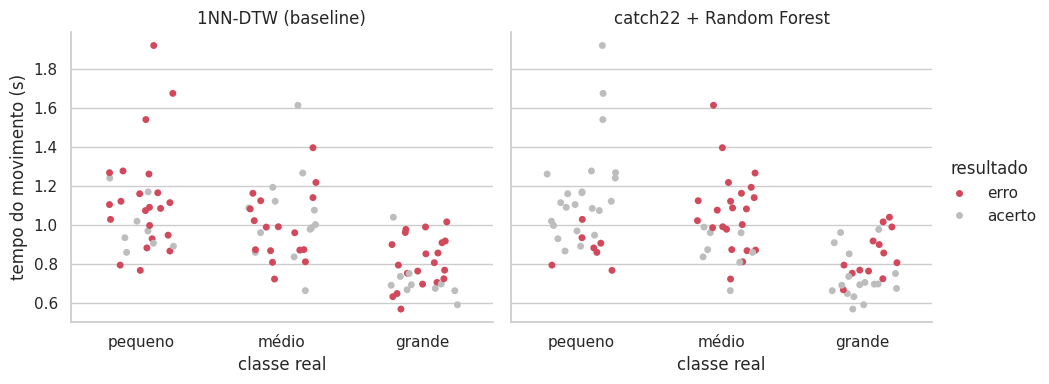

In [51]:
results = test.melt(id_vars=["classe", "movement_time_s"], value_vars=list(predictions), var_name="modelo", value_name="acertou")
results["resultado"] = results["acertou"].map({True: "acerto", False: "erro"})
grid = sns.catplot(data=results, x="classe", y="movement_time_s", col="modelo", hue="resultado",
                   palette={"acerto": "#bdbdbd", "erro": "#d1495b"}, kind="strip", jitter=0.25, height=4, aspect=1.2)
grid.set_axis_labels("classe real", "tempo do movimento (s)").set_titles("{col_name}")
plt.show()

O modelo aprende no treino quanto tempo cada classe costuma levar. Se isso muda de uma sessão para outra, os erros no teste acompanham essa mudança:

In [52]:
by_session = trials.pivot_table(index=["session", "conjunto"], columns="classe", values="movement_time_s", aggfunc="mean", observed=True)
print("Tempo médio do movimento (s) por sessão e classe:")
display(by_session.round(3))

miss = test.groupby(test["n_misses"] > 0)[list(predictions)].mean() * 100
miss.index = miss.index.map({False: "sem clique errado", True: "com clique errado"}).rename(None)
miss["movimentos"] = test.groupby(test["n_misses"] > 0).size().to_numpy()
print("Acurácia no teste (%) conforme o movimento teve ou não clique errado:")
display(miss.round(1))

Tempo médio do movimento (s) por sessão e classe:


,classe,pequeno,médio,grande
session,conjunto,,,
1,treino,1.055,0.866,0.795
2,teste,1.206,0.996,0.704
3,treino,1.037,0.904,0.727
4,teste,0.989,0.966,0.805
5,treino,1.180,0.746,0.833
6,teste,1.109,1.092,0.835


Acurácia no teste (%) conforme o movimento teve ou não clique errado:


,1NN-DTW (baseline),catch22 + Random Forest,movimentos
sem clique errado,37.0,55.6,81
com clique errado,11.1,33.3,9


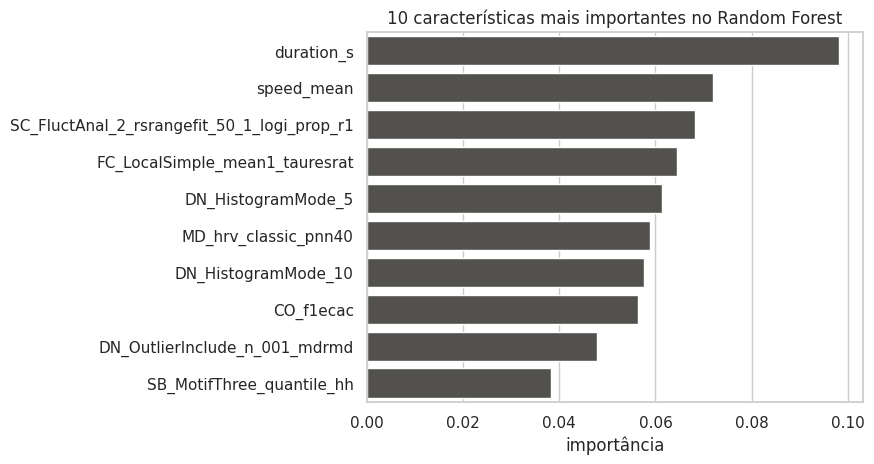

In [53]:
importance = pd.Series(forest.feature_importances_, index=feature_names).nlargest(10)
ax = sns.barplot(x=importance.to_numpy(), y=importance.index, color="#52514e")
ax.set(title="10 características mais importantes no Random Forest", xlabel="importância", ylabel="")
plt.show()

Por último, treinei o mesmo Random Forest usando só algumas características, para entender de onde vem o acerto. Isso não foi usado para escolher o modelo.

In [54]:
all_features, all_names = representations["catch22 + intensidade + duração"]
subsets = {
    "só duração": ["duration_s"],
    "intensidade + duração": ["speed_mean", "speed_std", "duration_s"],
    "catch22 + intensidade + duração": all_names,
}
ablation = {}
for name, columns in subsets.items():
    cols = [all_names.index(c) for c in columns]
    model = RandomForestClassifier(n_estimators=500, min_samples_leaf=int(best_rf["min_samples_leaf"]), random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(all_features[train_idx][:, cols], labels[train_idx])
    ablation[name] = accuracy_score(y_test, model.predict(all_features[test_idx][:, cols])) * 100
display(pd.Series(ablation, name="acurácia no teste (%)").round(1).to_frame())

,acurácia no teste (%)
só duração,38.9
intensidade + duração,55.6
catch22 + intensidade + duração,53.3


## 7. Conclusões

- O catch22 + Random Forest foi melhor que o 1NN-DTW, e pelo teste de McNemar a diferença não é por acaso. O 1NN-DTW ficou perto do acerto aleatório.
- O que mais separa as classes é a combinação da duração do movimento com a velocidade média: nos alvos pequenos o movimento demora mais e a velocidade é menor. Só a duração não foi suficiente, e as características de formato do catch22 acrescentaram pouco.
- Isso ajuda a entender o baseline. A z-normalização tira a informação de velocidade e o DTW compensa as diferenças de duração ao alinhar as séries, então sobra só o formato da curva, que é bem parecido entre as classes.
- A classe médio foi a mais difícil. Nas sessões de teste os movimentos até o alvo médio foram mais lentos do que nas sessões de treino, e muitos acabaram classificados como pequeno.
- Os movimentos em que errei o clique antes de acertar o alvo foram classificados pior pelos dois modelos.

## 8. Limitações

- Só eu participei da coleta, então o modelo aprendeu o meu jeito de usar o mouse.
- Usei uma única distância, um mouse, um monitor e a mesma configuração de ponteiro. Com outra distância o tempo do movimento muda, mesmo com o mesmo alvo.
- Meu estado variou bastante entre as sessões (sono, fome, cansaço, uma sessão feita durante uma reunião). Anotei isso, mas não controlei.
- Repeti a mesma tarefa em dois dias, então pode haver efeito de aprendizado.
- O resumo com os tempos no fim de cada sessão pode ter me incentivado a ir mais rápido nas sessões seguintes.
- A tarefa é de laboratório: no uso normal o cursor não sai sempre do mesmo ponto.
- Com 90 exemplos de teste, cada erro muda a acurácia em cerca de 1,1 ponto percentual, então diferenças pequenas entre modelos podem ser acaso.